Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [93]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [94]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_30400\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [95]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.5

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

## Calcul du traitement

### RNP

In [96]:
df_rnp = traitement(df_rnp)

### RP

In [97]:
df_rp = traitement(df_rp)

### UI

In [98]:
df_ui = traitement(df_ui)

### UD

In [99]:
df_ud = traitement(df_ud)

## DID

Definition du modele

In [117]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [1995, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_pres', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_pres'] = df_pres['vote_RN_pres'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('int64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_pres',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=3,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.001169 0.000833 -0.000464 0.002802 45317.0     3396.0 45317.0       3396.0
            Effect_2  0.004536 0.001172  0.002239 0.006832 34498.0     2739.0 34498.0       2739.0
            Effect_3  0.007836 0.001613  0.004675 0.010997 24693.0     2089.0 24693.0       2089.0
Average_Total_Effect  0.003984 0.000958  0.002106 0.005862 50170.0     8224.0 50170.0       8224.0
           Placebo_1 -0.000263 0.000838 -0.001907 0.001380 34899.0     3163.0 34899.0       3163.0
           Placebo_2 -0.001623 0.001382 -0.004331 0.001085 15840.0     1517.0 15840.0       1517.0
Test of joint nullity of the effects: p-value = 0.000009
Test of joint nullity of the placebos: p-value = 0.499083

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


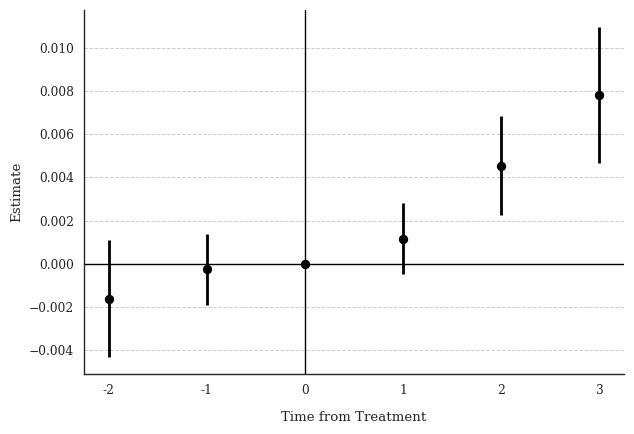

In [113]:
DID(df_rnp)

In [111]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = -0.003551
se_placebo =  0.001448

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : -2.452
P-value du Placebo : 0.014


### RP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.002360 0.000802  0.000787 0.003933 42735.0     3143.0 42735.0       3143.0
            Effect_2  0.004605 0.001113  0.002423 0.006786 32626.0     2598.0 32626.0       2598.0
            Effect_3  0.006026 0.001518  0.003050 0.009002 23437.0     1984.0 23437.0       1984.0
Average_Total_Effect  0.004057 0.000949  0.002197 0.005916 47329.0     7725.0 47329.0       7725.0
           Placebo_1  0.000362 0.000810 -0.001225 0.001950 32960.0     2943.0 32960.0       2943.0
           Placebo_2 -0.002716 0.001395 -0.005449 0.000017 15077.0     1403.0 15077.0       1403.0
Test of joint nullity of the effects: p-value = 0.000247
Test of joint nullity of the placebos: p-value = 0.064358

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


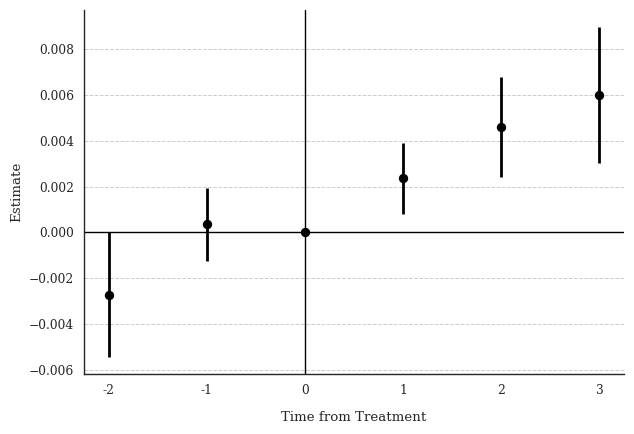

In [114]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.007091 0.001196  0.004747  0.009434 14429.0      777.0 14429.0        777.0
            Effect_2  0.012274 0.001897  0.008556  0.015992 11183.0      651.0 11183.0        651.0
            Effect_3  0.008732 0.002757  0.003329  0.014135  8090.0      480.0  8090.0        480.0
Average_Total_Effect  0.009272 0.001587  0.006161  0.012383 15562.0     1908.0 15562.0       1908.0
           Placebo_1 -0.003888 0.001267 -0.006372 -0.001405 11255.0      725.0 11255.0        725.0
           Placebo_2 -0.009295 0.002277 -0.013757 -0.004832  5317.0      399.0  5317.0        399.0
Test of joint nullity of the effects: p-value = 0.000000
Test of joint nullity of the placebos: p-value = 0.000062

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


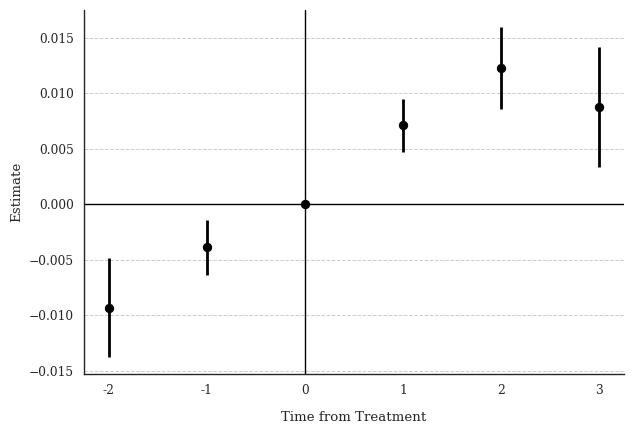

In [115]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.011115 0.003832  0.003604  0.018625 3349.0       69.0 3349.0         69.0
            Effect_2  0.025478 0.006222  0.013283  0.037673 2648.0       61.0 2648.0         61.0
            Effect_3  0.023503 0.009019  0.005826  0.041180 1949.0       38.0 1949.0         38.0
Average_Total_Effect  0.019132 0.005115  0.009107  0.029157 3448.0      168.0 3448.0        168.0
           Placebo_1 -0.014198 0.003424 -0.020909 -0.007488 2655.0       68.0 2655.0         68.0
           Placebo_2 -0.018353 0.006143 -0.030394 -0.006312 1300.0       44.0 1300.0         44.0
Test of joint nullity of the effects: p-value = 0.000682
Test of joint nullity of the placebos: p-value = 0.000112

The development of this package was funded by the European Union.
ERC REALLYCREDIBLE - GA N. 101043899


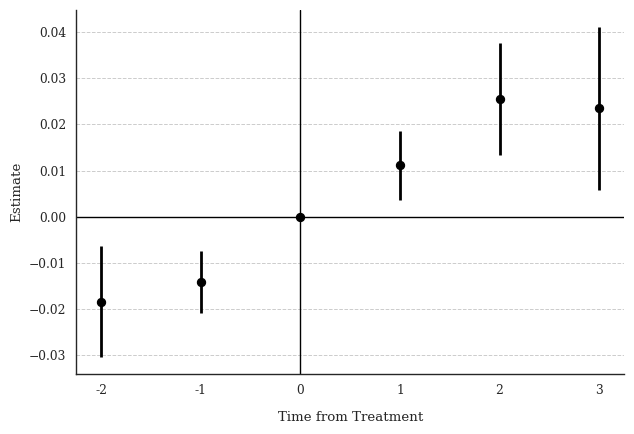

In [116]:
DID(df_ud)